<a href="https://colab.research.google.com/github/GUDAYASHASWINI01/Python/blob/main/K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the Dataset

  This input file contains the basic onformation (ID,age,gender,income,spending score) about the customers of the mall. spending score is something you assign to the customer based on your defined parameters like customer behaviour and purchasing data

**K-means clustering for customer data**

In [ ]:
!pip install plotly

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly as py
import plotly.graph_objs as go


from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")


**Data exploration**

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
#check for null values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


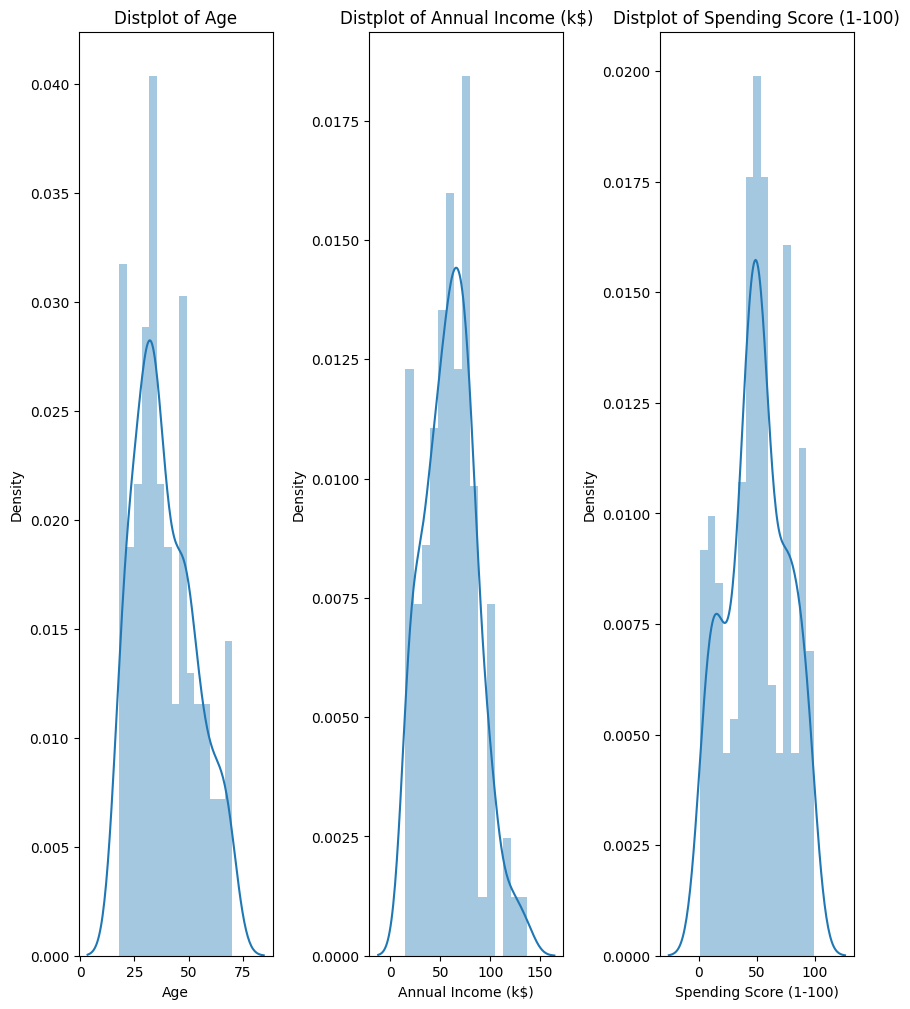

In [ ]:
#check the distributiopn of the data in age,annual income,  spending score
#hint :- Try with histogram where 'Kde' is true
#now we use subplot along with 'distplot'
plt.figure(1,figsize=(10,12))
n = 0
for x in ['Age','Annual Income (k$)','Spending Score (1-100)']:
  n = n+1
  plt.subplot(1,3,n)
  plt.subplots_adjust(hspace=0.5,wspace=0.5)
  sns.distplot(df[x],bins=15)
  plt.title('Distplot of {}'.format(x))
plt.show()

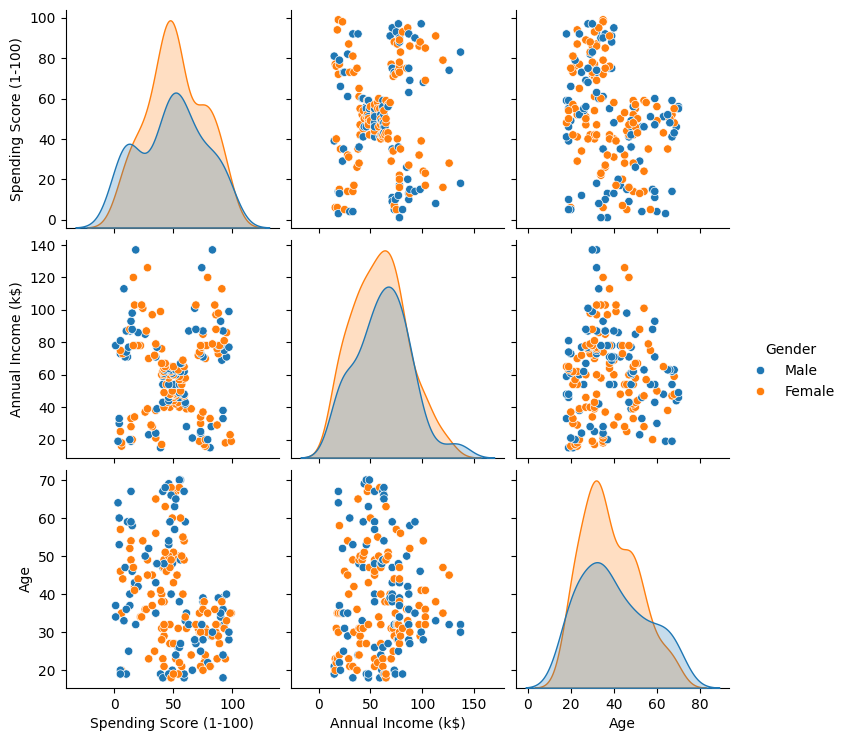

In [ ]:
#use pair plot to check the distribution of data w.r.t gender
sns.pairplot(df,vars=['Spending Score (1-100)','Annual Income (k$)','Age'],hue='Gender')

**Decide the K value**  --> We need to use elbow chart

In [ ]:
X1 = df[['Spending Score (1-100)','Age','Annual Income (k$)']].iloc[:,:].values
inertia = []
for n in range(1,15):
  algorithm = KMeans(
      n_clusters = n,
      init = 'k-means++',
      tol=0.0001,
      random_state=42
  )
  algorithm.fit(X1)
  inertia.append(algorithm.inertia_)
#tol mean tolerence to stop iterations in k-means

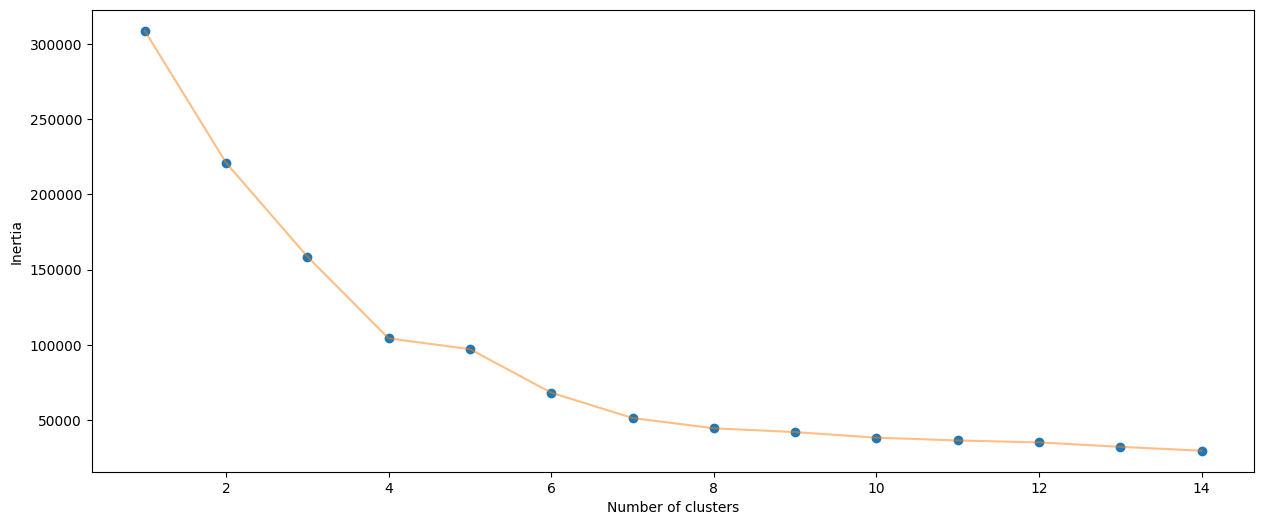

In [ ]:
plt.figure(1,figsize=(15,6))
plt.plot(np.arange(1,15),inertia,'o')
plt.plot(np.arange(1,15),inertia,'-',alpha=0.5)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

apply Kmeans for k = 4

In [ ]:
algorithm = KMeans(
      n_clusters = 4,
      init = 'k-means++',
      max_iter = 300,
      tol=0.0001,
      random_state=42,
      algorithm = 'elkan'
  )

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_


#there 2 alorightms used by k-means for faster clustering process --> LLOYD, ELKAN
#lloyd --> standard k-means algorithm
#elkan --> optimized version

#**2D image**

In [ ]:
h = 0.02
x_min,x_max = X1[:,0].min() - 1, X1[:,0].max()+1
y_min,y_max = X1[:,1].min() - 1, X1[:,1].max()+1
xx,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
z = algorithm.predict(np.c_[xx.ravel(),yy.ravel()])

ValueError: X has 2 features, but KMeans is expecting 3 features as input.

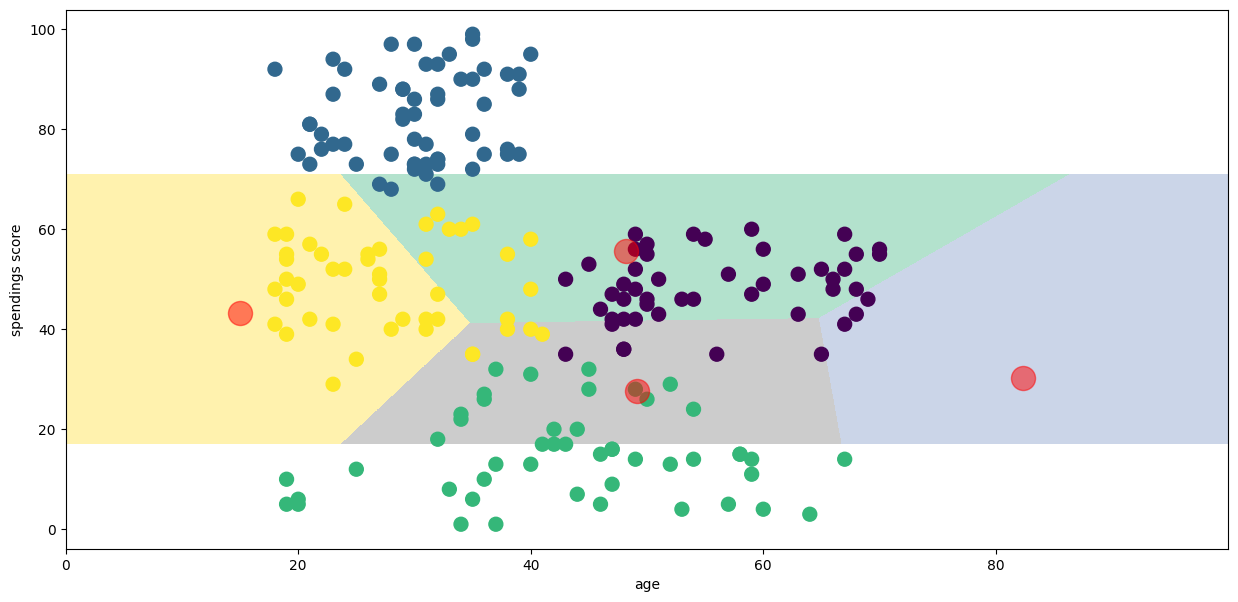

In [ ]:
plt.figure(1,figsize=(15,7))
plt.clf()
z = z.reshape(xx.shape)
plt.imshow(z,interpolation="nearest",
           extent=(xx.min(),xx.max(),yy.min(),yy.max()),
           cmap=plt.cm.Pastel2,aspect='auto',origin='lower')


plt.scatter(x="Age",y="Spending Score (1-100)",data=df,c=labels1,s=100)
plt.scatter(x=centroids1[:,0],y=centroids1[:,1],s=300,c='red',alpha=0.5)
plt.ylabel('spendings score')
plt.xlabel('age')
plt.show()

#**3D image**

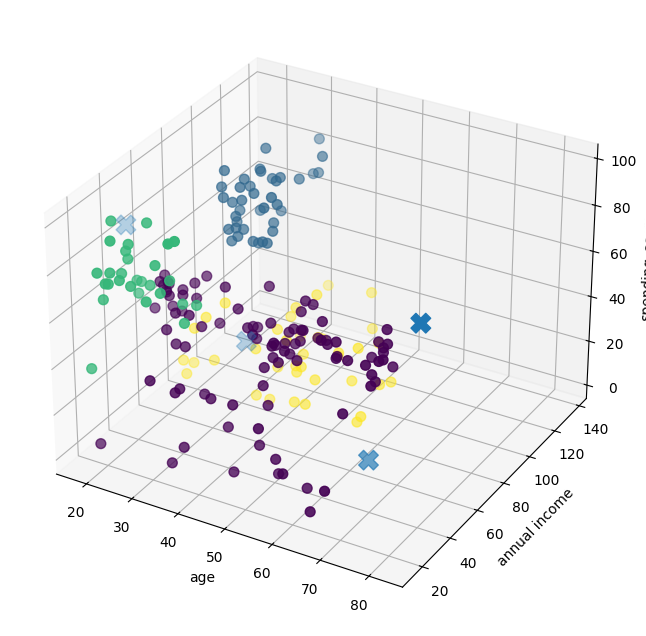

In [ ]:
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    X1['Age'],

    X1['Spending Score (1-100)'],
    c= labels1,
    s = 50
)
ax.scatter(
    centroids1[:,0],
    centroids1[:,1],
    centroids1[:,2],
    s=200,
    marker="X"
)

ax.set_xlabel("age")
ax.set_ylabel("annual income")
ax.set_zlabel("spending_score")
plt.show()

apply k = 5

In [ ]:
algorithm = (KMeans(
      n_clusters = 5,
      init = 'k-means++',
      max_iter = 300,
      tol=0.0001,
      random_state=42,
      algorithm = 'elkan'
  ))

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

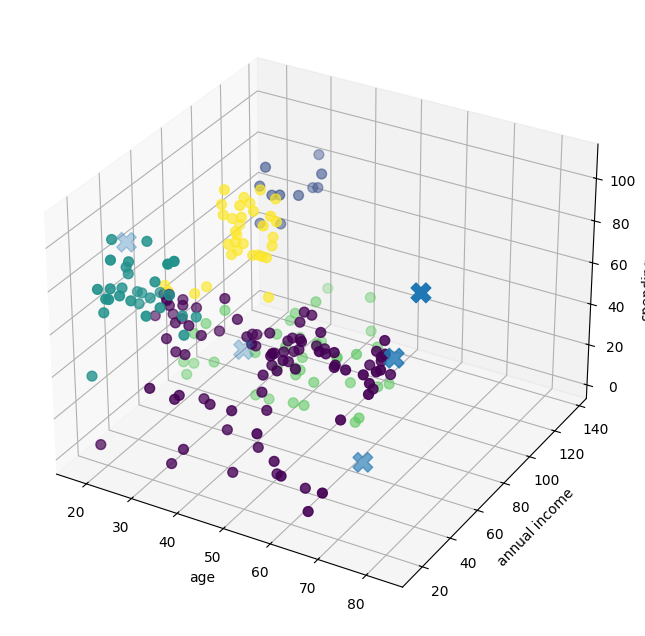

In [ ]:
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    X1['Age'],
    X1['Annual Income (k$)'],
    X1['Spending Score (1-100)'],
    c= labels1,
    s = 50
)
ax.scatter(
    centroids1[:,0],
    centroids1[:,1],
    centroids1[:,2],
    s=200,
    marker="X"
)

ax.set_xlabel("age")
ax.set_ylabel("annual income")
ax.set_zlabel("spending_score")
plt.show()

apply k = 6

In [ ]:
algorithm = (KMeans(
      n_clusters = 6,
      init = 'k-means++',
      max_iter = 300,
      tol=0.0001,
      random_state=42,
      algorithm = 'elkan'
  ))

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

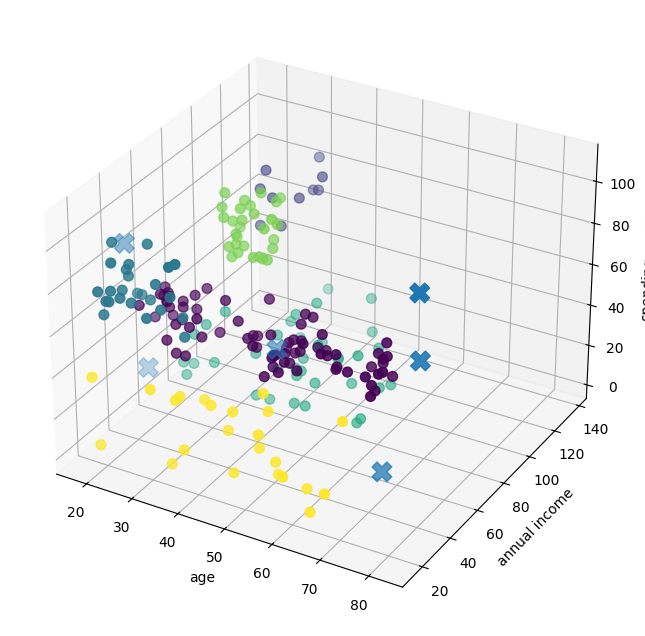

In [ ]:
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    X1['Age'],
    X1['Annual Income (k$)'],
    X1['Spending Score (1-100)'],
    c= labels1,
    s = 50
)
ax.scatter(
    centroids1[:,0],
    centroids1[:,1],
    centroids1[:,2],
    s=200,
    marker="X"
)

ax.set_xlabel("age")
ax.set_ylabel("annual income")
ax.set_zlabel("spending_score")
plt.show()

In [ ]:
algorithm = (KMeans(
      n_clusters = 7,
      init = 'k-means++',
      max_iter = 300,
      tol=0.0001,
      random_state=42,
      algorithm = 'elkan'
  ))

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

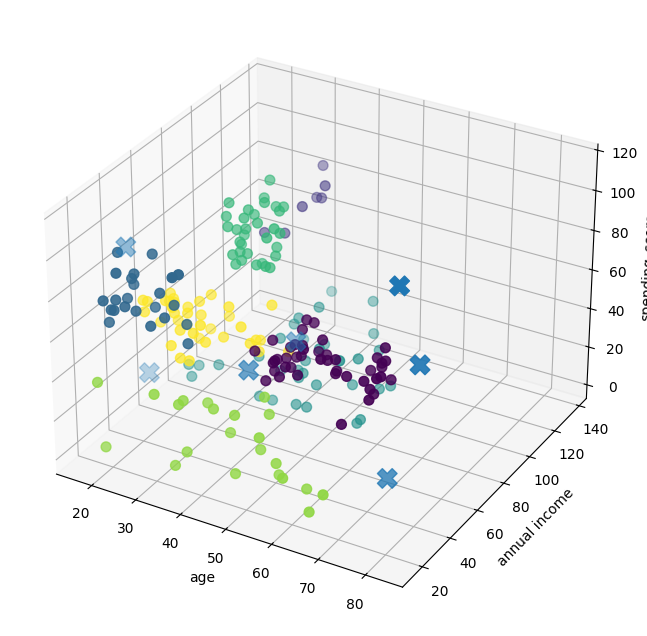

In [ ]:
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    X1['Age'],
    X1['Annual Income (k$)'],
    X1['Spending Score (1-100)'],
    c= labels1,
    s = 50
)
ax.scatter(
    centroids1[:,0],
    centroids1[:,1],
    centroids1[:,2],
    s=200,
    marker="X"
)

ax.set_xlabel("age")
ax.set_ylabel("annual income")
ax.set_zlabel("spending_score")
plt.show()